In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('Divar.csv')

C:\Users\Ramtin\AppData\Local\Temp\ipykernel_18684\1116618770.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Divar.csv')


C:\Users\Ramtin\AppData\Local\Temp\ipykernel_18684\903377856.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat2_counts.values, y=cat2_counts.index, ax=axes[0], palette='crest')
C:\Users\Ramtin\AppData\Local\Temp\ipykernel_18684\903377856.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat3_counts.values, y=cat3_counts.index, ax=axes[1], palette='flare')


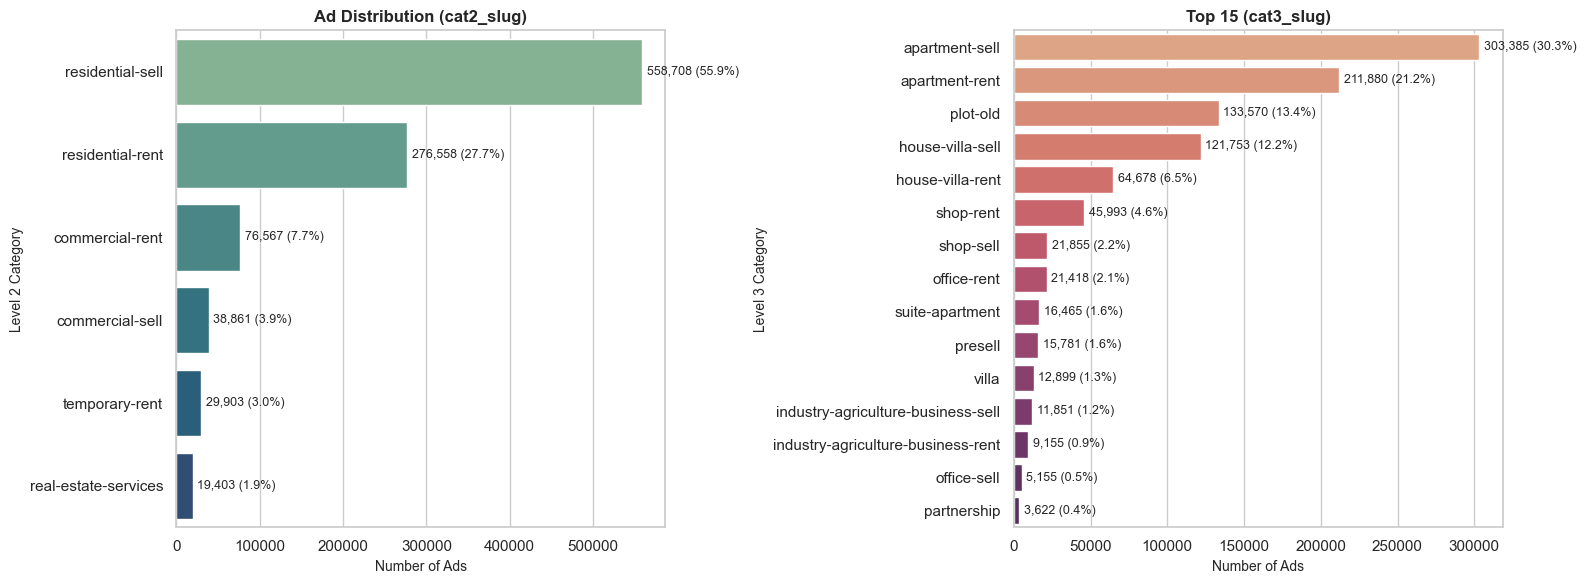

In [4]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

total_ads = len(df)

cat2_counts = df['cat2_slug'].value_counts()

sns.barplot(x=cat2_counts.values, y=cat2_counts.index, ax=axes[0], palette='crest')

axes[0].set_title('Ad Distribution (cat2_slug)', fontsize=12, weight='bold')
axes[0].set_xlabel('Number of Ads', fontsize=10)
axes[0].set_ylabel('Level 2 Category', fontsize=10)

for i, val in enumerate(cat2_counts.values):
    pct = (val / total_ads) * 100
    axes[0].text(val + (max(cat2_counts.values) * 0.01), i, f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)

top_n = 15
cat3_counts = df['cat3_slug'].value_counts().head(top_n)
sns.barplot(x=cat3_counts.values, y=cat3_counts.index, ax=axes[1], palette='flare')

axes[1].set_title(f'Top {top_n} (cat3_slug)', fontsize=12, weight='bold')
axes[1].set_xlabel('Number of Ads', fontsize=10)
axes[1].set_ylabel('Level 3 Category', fontsize=10)

for i, val in enumerate(cat3_counts.values):
    pct = (val / total_ads) * 100
    axes[1].text(val + (max(cat3_counts.values) * 0.01), i, f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

,deal_type_sell,deal_type_rent,month
0,0,0,8
1,1,0,5
2,0,1,10
3,0,1,6
4,1,0,5
...,...,...,...
999995,1,0,7
999996,0,1,7
999997,1,0,11
999998,0,0,9


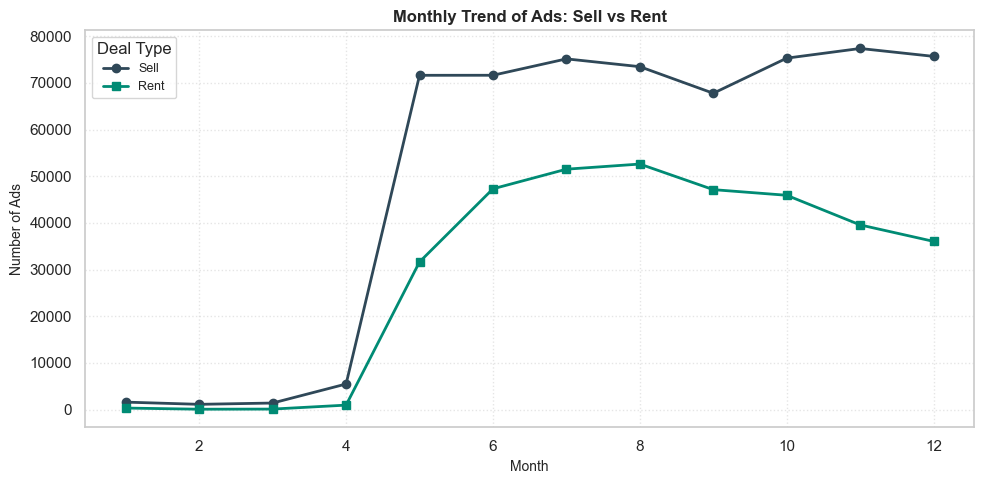

,deal_type_sell,deal_type_rent
month,,
1,1593,322
2,1120,74
3,1398,103
4,5476,952
5,71621,31633
6,71631,47299
7,75142,51505
8,73470,52604
9,67773,47122


In [8]:
df_clean = pd.read_parquet('../preprocessing_output_v2.parquet')
display(df_clean[['deal_type_sell', 'deal_type_rent', 'month']])
monthly_trends = df_clean.groupby('month')[['deal_type_sell', 'deal_type_rent']].sum().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(monthly_trends.index, monthly_trends['deal_type_sell'],  marker='o',  markersize=6, linewidth=2,  color='#2F4858',  label='Sell')

plt.plot(monthly_trends.index,  monthly_trends['deal_type_rent'], marker='s',  markersize=6, linewidth=2,  color='#008B74',  label='Rent')
plt.title('Monthly Trend of Ads: Sell vs Rent', fontsize=12, weight='bold')
plt.xlabel('Month', fontsize=10)
plt.ylabel('Number of Ads', fontsize=10)

plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(title='Deal Type', fontsize=9)

plt.tight_layout()
plt.show()

display(monthly_trends)

Ad counts by city :
city_slug
tehran     143082
mashhad     37358
karaj       36037
isfahan     24772
shiraz      19947
Name: count, dtype: int64


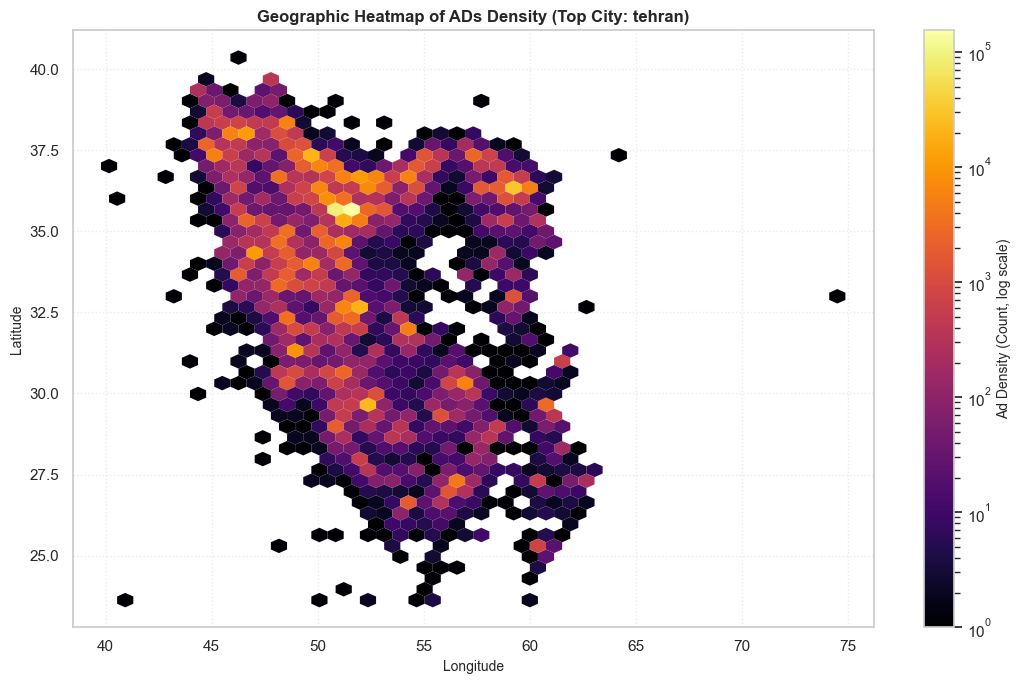

In [ ]:
from matplotlib.colors import LogNorm

df_geo = df[['city_slug', 'location_latitude', 'location_longitude']].dropna()

city_counts = df_geo['city_slug'].value_counts()
top_city = city_counts.index[0]
top_city_count = city_counts.iloc[0]

print("Ad counts by city :")
print(city_counts.head(5))

plt.figure(figsize=(11, 7))

heatmap = plt.hexbin(df_geo['location_longitude'], df_geo['location_latitude'], gridsize=45, cmap='inferno', mincnt=1, norm=LogNorm(vmin=1), edgecolors='none')

cbar = plt.colorbar(heatmap)
cbar.set_label('Ad Density (Count, log scale)', fontsize=10)

plt.title(f'Geographic Heatmap of ADs Density (Top City: {top_city})',fontsize=12, weight='bold')
plt.xlabel('Longitude', fontsize=10)
plt.ylabel('Latitude', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()